# Kaggle Guide

# 1. 데이터 셋 확인

In [1]:
# !pip install keras tensorflow

In [2]:
# !pip install missingno

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Matplotlib의 시각화를 간편하고 세련되게 만든다.
import keras
import sklearn

In [4]:
plt.style.use('seaborn-v0_8') # Matplotlib 디자인에서 seaborn 스타일로 디자인(테마) 변경
sns.set(font_scale=2.5) # 글자 크기를 2.5배 키우기 위해 작성
import missingno as msno # 데이터의 빈칸을 확인하기 위해 시각화 라이브러리

In [5]:
import warnings
warnings.filterwarnings('ignore') # 워닝 메세지 생략하는 기능
%matplotlib inline

In [6]:
os.listdir(".")

['.ipynb_checkpoints',
 '1. Kaggle Guide.ipynb',
 'gender_submission.csv',
 'test.csv',
 'train.csv']

In [7]:
df_train= pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')
df_submit = pd.read_csv('gender_submission.csv')

In [8]:
df_train.shape, df_test.shape, df_submit.shape

((891, 12), (418, 11), (418, 2))

In [9]:
df_train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [10]:
df_submit.columns

Index(['PassengerId', 'Survived'], dtype='object')

In [11]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [12]:
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [13]:
df_submit.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


> **타이타닉 데이터 Feature 설명** <br>
- survival - 생존유무, target 값. (0 = 사망, 1 = 생존)
- pclass - 티켓 클래스. (1 = 1st, 2 = 2nd, 3 = 3rd)
- sex - 성별
- Age - 나이(세)
- sibsp - 함께 탑승한 형제자매, 배우자 수 총합
- parch - 함께 탑승한 부모, 자녀 수 총합
- ticket - 티켓 넘버
- fare - 탑승 요금
- cabin - 객실 넘버
- bembarked - 탑승 항구

In [14]:
df_train.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [15]:
df_train.describe() # discribe 메소드로 각 feature가 가진 통계치 변환

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [16]:
df_test.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


## 1.1 결측치 확인(Null Data) 확인

In [17]:
df_train.isnull().sum() / df_train.shape[0] # Age 피쳐에 약 20%, Cabin 피쳐에 약80%의 결측치가 있음을 확인

PassengerId    0.000000
Survived       0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.198653
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
Cabin          0.771044
Embarked       0.002245
dtype: float64

In [18]:
df_test.isnull().sum() / df_test.shape[0]

PassengerId    0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.205742
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.002392
Cabin          0.782297
Embarked       0.000000
dtype: float64

## 1.2 Target Label, Survived 확인
- Targer label이 어떤 distribution을 가지고 있는지 확인

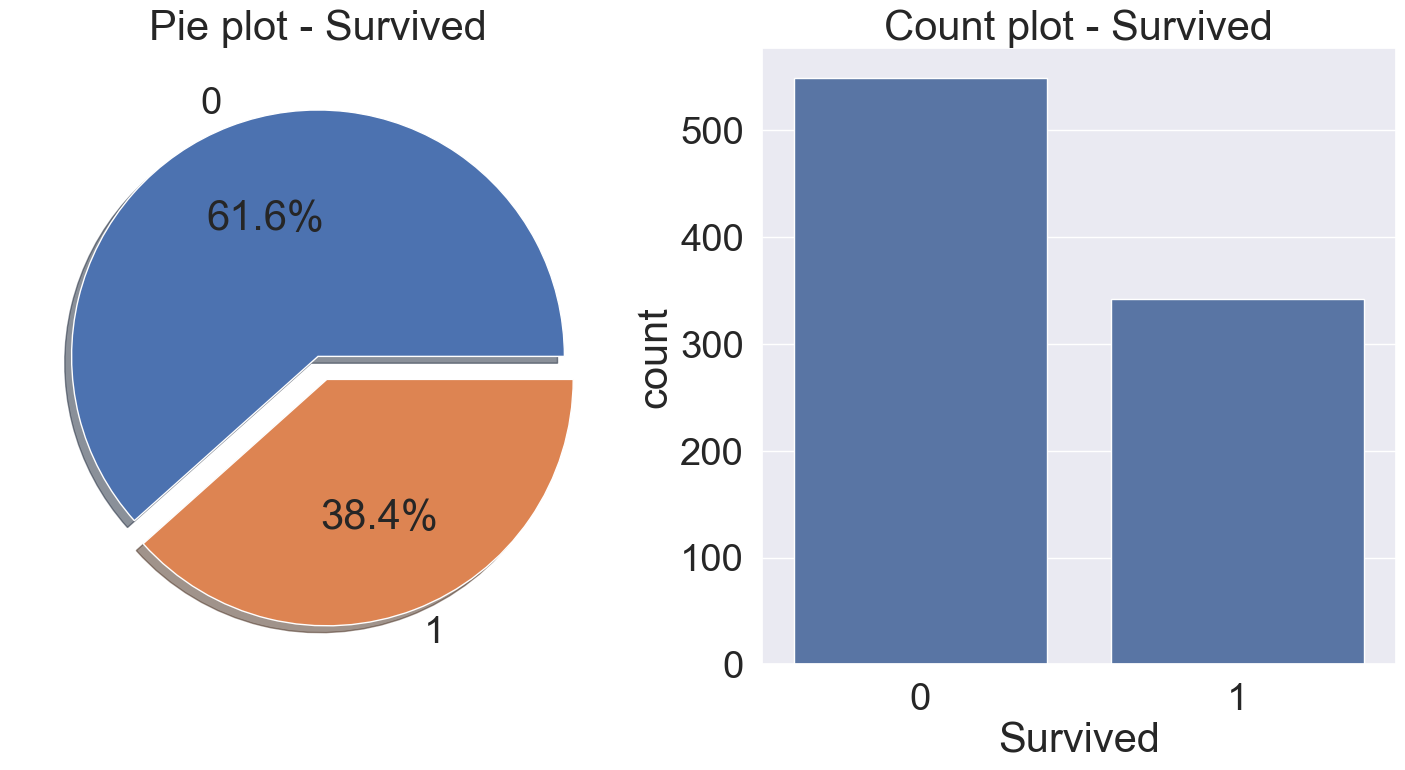

In [19]:
f, ax = plt.subplots(1, 2, figsize=(18,8)) # 행1 열2인 여러 그래프 그리기, f(figure) : 도화지 전체, ax(axes) : 각각의 그래프 칸
df_train['Survived'].value_counts().plot.pie(explode=[0, 0.1], autopct='%1.1f%%', ax=ax[0], shadow=True)
ax[0].set_title('Pie plot - Survived') # 생존자가 전체에서 차지하는 비율(%) 한눈에 파악하기
ax[0].set_ylabel('')
sns.countplot(x ='Survived', data=df_train, ax=ax[1]) # 정확히 몇명이 죽고 살았는지 수치를 직관적으로 파악하기
ax[1].set_title('Count plot - Survived')
plt.show()

df_train['Survived'].value_counts().plot.pie(explode=[0, 0.1], autopct='%1.1f%%', ax=ax[0], shadow=True) <br>
> **코드 해석:** <br>
`Survived` 컬럼의 개수를 세어서 파이 차트를 그릴 건데, 왼쪽 칸(`ax[0]`)에 그려줘. <br>
생존자 조각은 살짝 튀어나오게(`explode`) 하고, <br>
퍼센트도 소수점 한 자리까지 적어주고(`autopct`), <br>
그림자(`shadow`)까지 넣어서 예쁘게 만들어줘.

sns.countplot(x='Survived', data=df_train, ax=ax[1])
> **코드 해석:** <br>
시본(sns) 라이브러리의 막대그래프(`countplot`) 기능을 쓸 건데,<br>
'Survived' 컬럼에 있는 0(사망)과 1(생존)이 각각 몇 명인지 세어서 그려줘(`x='Survived'`)<br>
필요한 데이터는 df_train이라는 표에서 가져오고(`data=df_train`),<br>
이 막대그래프는 미리 나눠놓은 화면 중 **오른쪽 칸(`ax[1]`)**에 배치해줘.<br>

# 2. 탐색적 데이터 분석(EDA, Exploratory Data Analysis)
, 시각화 라이브러리 matplotlib, seaborn, plotly

## 2.1 Pclass
서열척도

In [20]:
df_train[['Pclass', 'Survived']].groupby(['Pclass'], as_index=True).count()

,Survived
Pclass,
1,216
2,184
3,491


> **코드해석**<br>
> df_train 표에서 **'Pclass'(객실 등급)**랑 'Survived'(생존 여부) 두 개의 기둥(컬럼)만 쏙 뽑아와서(`[['Pclass', 'Survived']]`),<br>
'Pclass' 등급별로 (1등석끼리, 2등석끼리, 3등석끼리) 사람들을 끼리끼리 묶어줘(`groupby(['Pclass'])`)<br>
그리고 각 등급별로 데이터가 몇 개씩 있는지 숫자를 세어줘(`.count()`)<br>
이때 그룹으로 묶은 'Pclass'를 표의 왼쪽 기준점(인덱스)으로 딱 박아줘(`as_index=True`)<br>

In [21]:
df_train[['Pclass', 'Survived']].groupby(['Pclass'], as_index=True).mean() # 생존율(%) 파악하기

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


In [22]:
df_train[['Pclass', 'Survived']].groupby(['Pclass'], as_index=True).sum() # Pclass 그룹 별 생존자 수의 합

,Survived
Pclass,
1,136
2,87
3,119


In [23]:
pd.crosstab(df_train['Pclass'], df_train['Survived'], margins=True) # 교차표(Cross Tabulation) 생성하기

Survived,0,1,All
Pclass,,,
1,80,136,216
2,97,87,184
3,372,119,491
All,549,342,891


> **코드해석** <br>
> 판다스(pd)야, 두 항목을 서로 교차시켜서 **빈도수 표(crosstab)**를 하나 만들어줘.<br>
**세로줄(행)**에는 'Pclass'(객실 등급)를 세워두고,<br>
**가로줄(열)**에는 'Survived'(생존 여부)를 배치해줘.<br>
그리고 마지막에 **가로·세로 합계(`margins=True`)**도 'All'이라는 이름으로 딱 붙여줘.

<Axes: xlabel='Pclass'>

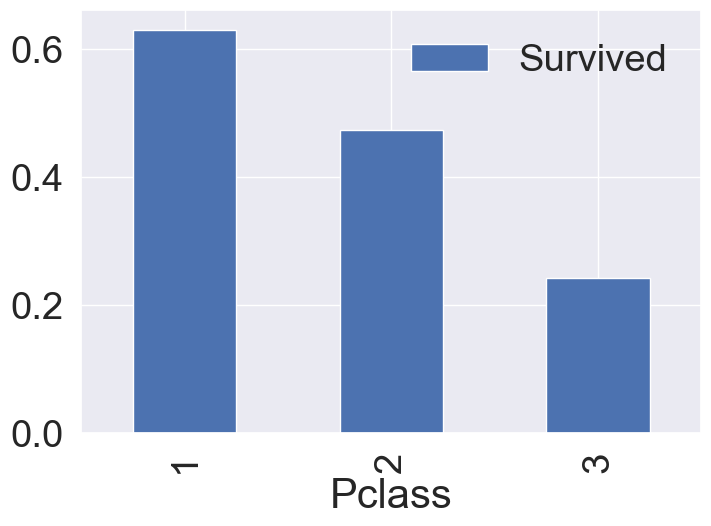

In [24]:
df_train[['Pclass', 'Survived']].groupby(['Pclass'], as_index=True).mean().plot.bar()

## 2.2 Sex

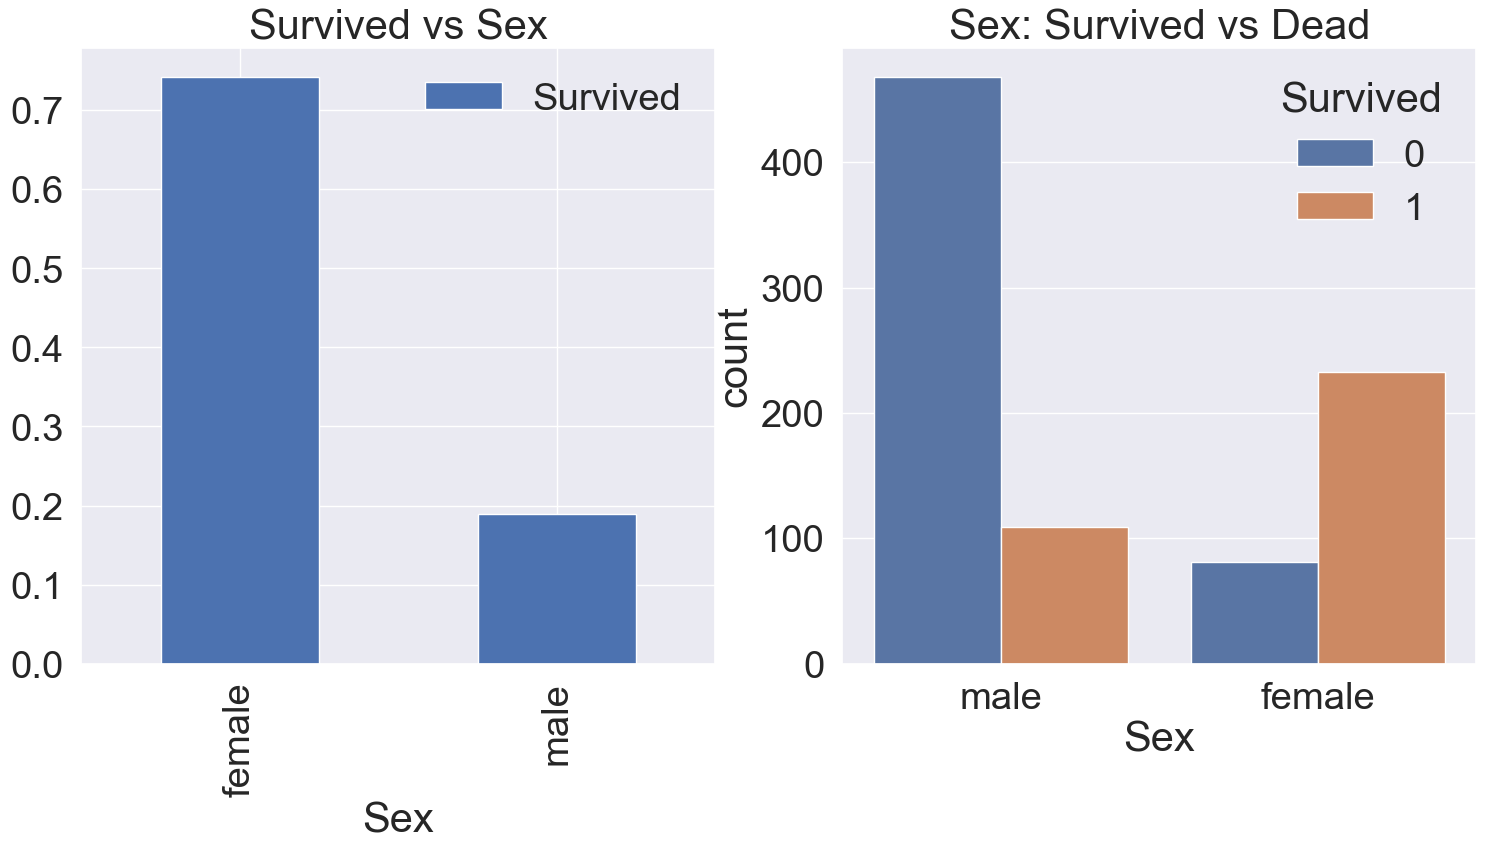

In [25]:
f, ax = plt.subplots(1, 2, figsize=(18, 8))
df_train[['Sex', 'Survived']].groupby(['Sex'], as_index=True).mean().plot.bar(ax=ax[0])
ax[0].set_title('Survived vs Sex')
sns.countplot(x='Sex', hue='Survived', data=df_train, ax=ax[1])
ax[1].set_title('Sex: Survived vs Dead')
plt.show()

> sns.countplot(x='Sex', hue='Survived', data=df_train, ax=ax[1]) <br>
>**코드해석** <br>
> 시본(sns)아, 개수를 세어서 막대그래프(`countplot`)를 그릴 건데,<br>
가로축(x)에는 'Sex'(성별)를 기준으로 'Male', 'Female' 기둥을 세워줘.<br>
여기서 핵심! 각 성별 기둥을 'Survived'(생존 여부)에 따라 색깔별로 쪼개서(`hue='Survived'`) 나란히 세워줘.<br>
데이터는 df_train에서 가져오고, 이 복합적인 그래프는 오른쪽 칸(`ax[1]`)에 예쁘게 넣어줘.

## 2.3 Both Sex and Pclass

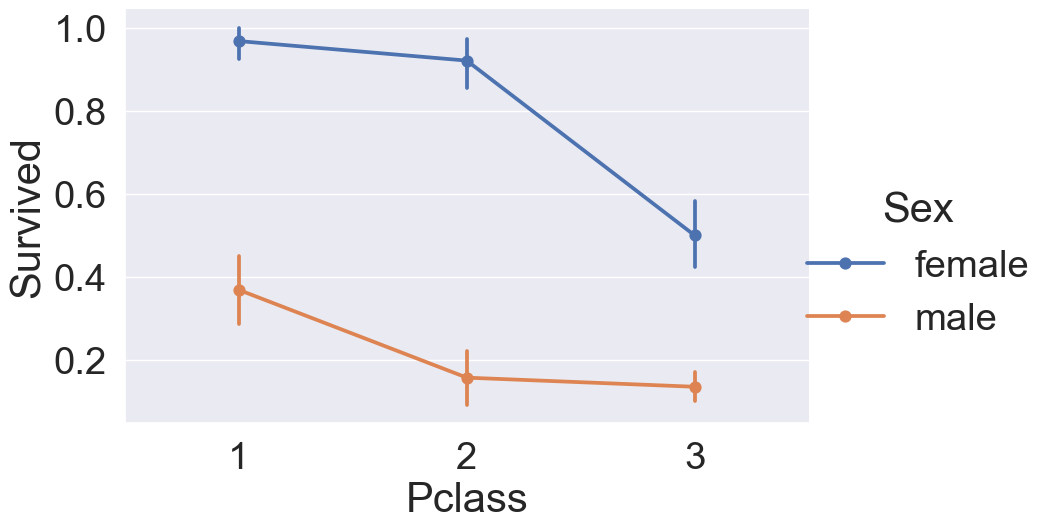

In [26]:
sns.catplot(x='Pclass', y='Survived', hue='Sex', data=df_train, kind='point', height=6, aspect=1.5)

> **코드해석** <br>
> 시본(sns)아, 범주형 그래프(`catplot`)를 그릴 건데,<br>
가로축(x)은 **'Pclass'(객실 등급)**로 나누고,<br>
세로축(y)은 **'Survived'(생존율)**를 계산해서 보여줘.<br>
이때 성별(`hue='Sex'`)에 따라 색깔을 다르게 해서 남녀 차이를 보여주고,<br>
그래프 형태는 **점과 선으로 이어진 형태(`kind='point'`)**로 해줘.<br>
데이터는 df_train에서 가져오고,<br>
그래프 높이는 6(height=6), **가로 길이는 높이의 1.5배(`aspect=1.5`)**로 큼직하게 그려줘.<br>

## 2.4 Age

In [27]:
print(f"제일 나이 많은 탑승객 : {df_train['Age'].max():.1f}Years")
print(f"제일 어린 탑승객 : {df_train['Age'].min():.1f}Years")
print(f"탑승객 평균 나이: {df_train['Age'].mean():.1f}Years")

제일 나이 많은 탑승객 : 80.0Years
제일 어린 탑승객 : 0.4Years
탑승객 평균 나이: 29.7Years


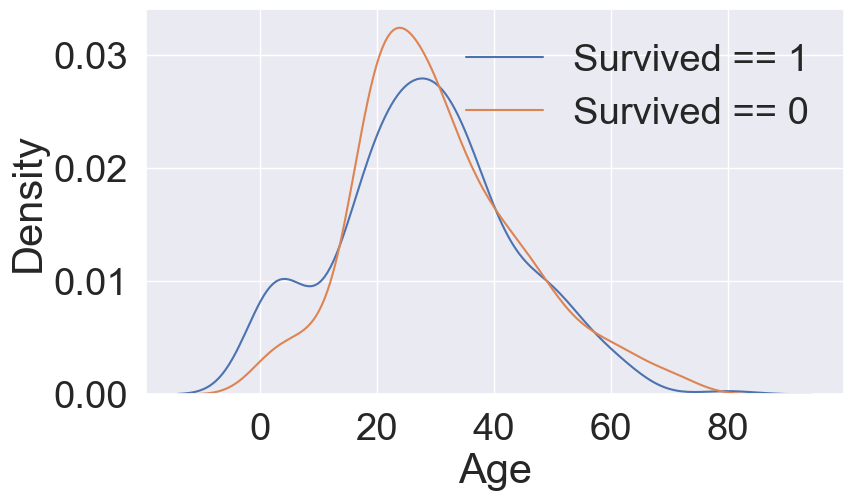

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(9, 5))
sns.kdeplot(df_train[df_train['Survived'] == 1]['Age'], ax=ax) # 불리언 인덱싱(조건 필터링)
sns.kdeplot(df_train[df_train['Survived'] == 0]['Age'], ax=ax)
plt.legend(['Survived == 1', 'Survived == 0'])
plt.show()

### kdeplot이란?
> **이름:** Kernel Density Estimation (커널 밀도 추정) 그래프<br>
**쉽게 말하면:** **"부드러워진 히스토그램"**입니다.<br>
**특징:** 히스토그램은 막대기로 되어 있어서 투박하고 구간을 어떻게 나누냐에 따라 모양이 확확 바뀌죠? kdeplot은 이를 부드러운 곡선으로 연결해서 데이터가 어디에 많이 모여 있는지(밀도)를 마치 산봉우리처럼 보여줍니다.<br>
**해석 방법:** 선이 높게 솟아오를수록 그 부분에 데이터가 많이 밀집되어 있다는 뜻입니다. (예: 20대 부분의 선이 높으면 승객 중 20대가 가장 많다는 뜻)

>sns.kdeplot(df_train[df_train['Survived'] == 1]['Age'], ax=ax)
> **코드해석**
>시본(sns)아, 부드러운 곡선 그래프(`kdeplot`)를 그려줘.<br>
그릴 데이터는 말이야, 전체 데이터(df_train) 중에서 **생존자(`'Survived' == 1`)들만 골라낸 다음, 그들의 나이('Age')**만 모아서 가져와서 그려줘.<br>
그래프는 미리 준비한 도화지(ax)에 그려넣어줘.<br>

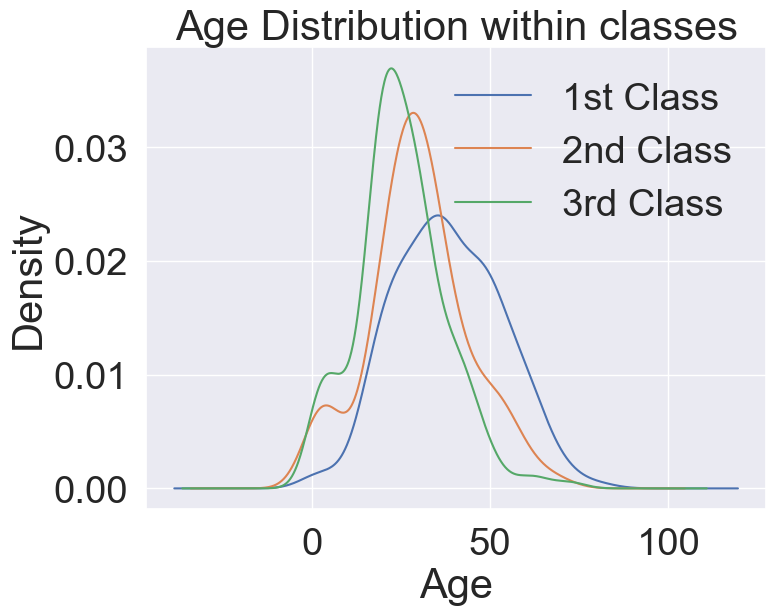

In [29]:
plt.figure(figsize=(8,6))
df_train['Age'][df_train['Pclass'] == 1].plot(kind='kde')
df_train['Age'][df_train['Pclass'] == 2].plot(kind='kde')
df_train['Age'][df_train['Pclass'] == 3].plot(kind='kde')

plt.xlabel('Age')
plt.title('Age Distribution within classes')
plt.legend(['1st Class', '2nd Class', '3rd Class'])

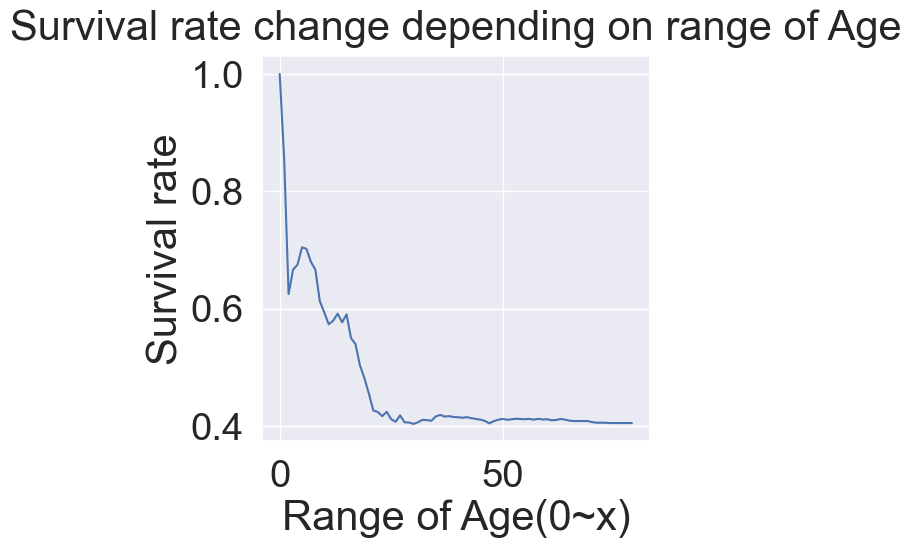

In [30]:
cumulate_survival_ratio = []
for i in range(1, 81):
    cumulate_survival_ratio.append(df_train[df_train['Age']<i]['Survived'].sum() / len(df_train[df_train['Age']<i]['Survived']))

plt.figure(figsize=(5, 5))
plt.plot(cumulate_survival_ratio)
plt.title('Survival rate change depending on range of Age', y=1.02)
plt.ylabel('Survival rate')
plt.xlabel('Range of Age(0~x)')
plt.show()

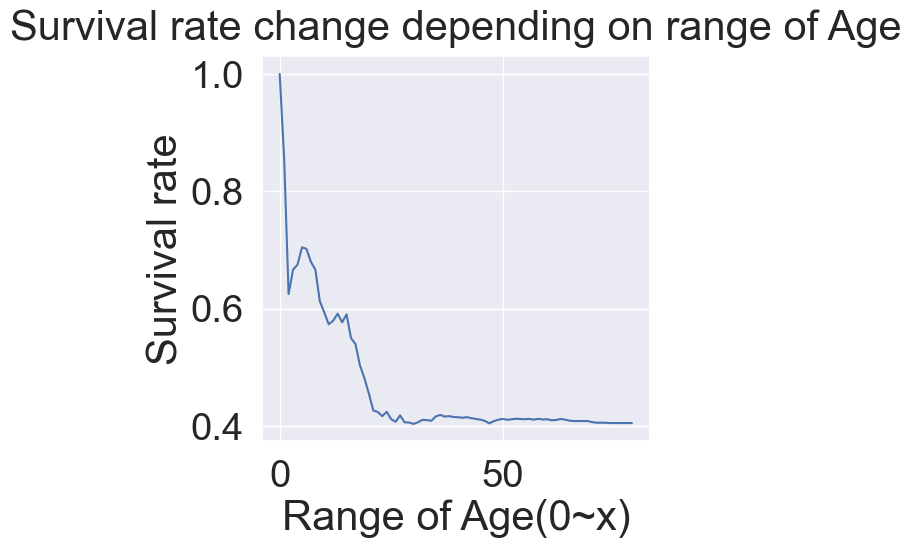

In [31]:
# 'Age' 변수가 'Survived'에 미치는 영향 시각화 /특정 연령층이 전체 생존율을 어떻게 변화시키는지 파악하기
cumulate_survival_ratio = []
for i in range(1, 81):
    survival_rate = df_train[df_train['Age'] < i]['Survived'].mean()
    cumulate_survival_ratio.append(survival_rate)

plt.figure(figsize=(5, 5))
plt.plot(cumulate_survival_ratio)
plt.title('Survival rate change depending on range of Age', y=1.02)
plt.ylabel('Survival rate')
plt.xlabel('Range of Age(0~x)')
plt.show()

> **코드해석**<br>
> commulate_survival_ratio라는 빈 바구니(리스트)를 준비해줘.<br>
i가 1부터 80이 될 때까지 반복할 건데(`for i in range`),<br>
전체 데이터(df_train) 중에서 **나이가 i살보다 적은 사람들(`df_train['Age'] < i`)**만 골라내서,<br>
그 사람들의 **생존 여부('Survived')의 평균(.mean())**을 내줘. (1은 생존, 0은 사망이므로 평균을 내면 바로 생존율이 됩니다!)<br>
계산된 그 값을 아까 만든 바구니에 차곡차곡 넣어줘(`.append`)<br>
> <br>
> **Append는 왜 있는걸까?**<br>
> append는 파이썬 리스트(List)의 맨 뒤에 새로운 값을 추가하는 함수입니다.<br>
**이유:** for 문이 돌아가면서 계산된 survival_rate는 한 번 쓰고 사라지는 휘발성 변수입니다. 만약 append를 하지 않으면,<br>
>  **루프가 끝난 뒤에는 마지막 i=80일 때의 값만 남게 됩니다.**<br>
**목적:** 우리가 원하는 건 **"1세 미만일 때 생존율, 2세 미만일 때 생존율, ..., 80세 미만일 때 생존율"**이라는<br>
>  **80개의 데이터를 모으는 것**입니다. cumulate_survival_ratio라는 빈 리스트(바구니)에 계산 결과가 나올 때마다 차곡차곡 담아두는 역할을 합니다.<br>

<Axes: xlabel='Age_band'>

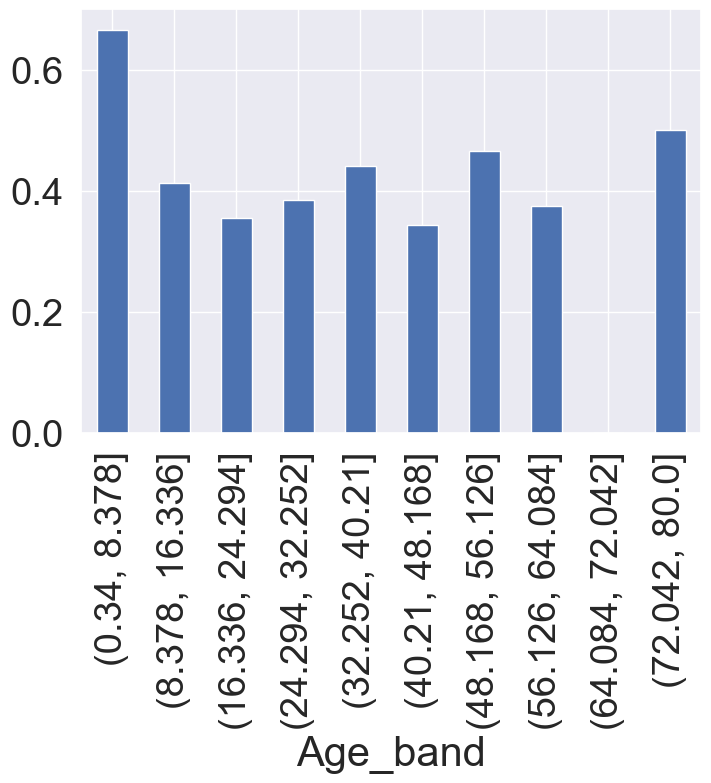

In [32]:
df_train['Age_band'] = pd.cut(df_train['Age'], 10) # 범위를 기준으로(최솟값~최대값) 동일한 길이로 10등분하기
df_train.groupby('Age_band')['Survived'].mean().plot(kind='bar') # 나이 구간별로 생존율 확인해보기

In [33]:
from scipy import stats  # SciPy의 통계 모듈 임포트
import pandas as pd

# 1. 데이터 준비 (결측치가 없는 데이터만 추출)
# Age와 Survived 컬럼만 가져오되, Age가 비어있는 행은 버립니다.
temp_df = df_train[['Age', 'Survived']].dropna()

# 2. 점-이연 상관계수 계산
# stats.pointbiserialr(수치형_데이터, 이진_데이터)
correlation, p_value = stats.pointbiserialr(temp_df['Age'], temp_df['Survived'])

print(f"상관계수(Correlation Coefficient): {correlation:.4f}")
print(f"P-값(p-value): {p_value:.4f}")

# 3. 결과 해석
if p_value < 0.05:
    print("해석: 나이와 생존 여부 사이에는 통계적으로 유의미한 관계가 있습니다.")
else:
    print("해석: 통계적으로 유의미한 관계를 찾기 어렵습니다.")

상관계수(Correlation Coefficient): -0.0772
P-값(p-value): 0.0391
해석: 나이와 생존 여부 사이에는 통계적으로 유의미한 관계가 있습니다.


## 2.5 Embarked
탑승한 항구

In [34]:
df_train['Embarked'].unique() # 중복을 제거하고 고유한 값(카테고리)만 확인하기 / 결측치(NaN)와 이상치도 확인 가능

array(['S', 'C', 'Q', nan], dtype=object)

<Axes: xlabel='Embarked'>

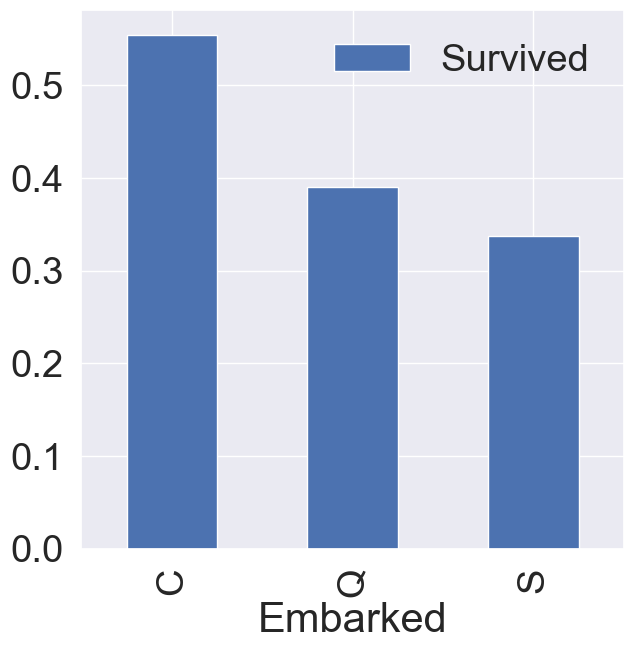

In [35]:
f, ax = plt.subplots(1, 1, figsize=(7, 7))
df_train[['Embarked', 'Survived']].groupby(['Embarked'], as_index=True).mean().sort_values(by='Survived', ascending=False).plot.bar(ax=ax)

>**코드해석**<br>
>`df_train[['Embarked', 'Survived']]`<br>
전체 표에서 우리가 분석할 '항구'와 '생존여부' 두 기둥(컬럼)만 가져옵니다.<br>
`.groupby(['Embarked'], as_index=True)`<br>
항구 이름(C, Q, S)을 기준으로 사람들을 끼리끼리 모읍니다. as_index=True는 항구 이름을 표의 행 이름(인덱스)으로 쓰겠다는 뜻입니다.<br>
`.mean()`<br>
 0(사망)과 1(생존)의 평균을 내서 항구별 생존율을 구하는 핵심 단계입니다.<br>
`.sort_values(by='Survived', ascending=False)`<br>
결과를 그냥 두지 않고, Survived(생존율)가 큰 값부터 작은 값 순서로(내림차순, ascending=False) 정렬합니다.<br>
`.plot.bar(ax=ax)`<br>
마지막으로 이 숫자를 막대 그래프로 시각화합니다. 괄호 안의 ax=ax는 미리 만들어둔 도화지(그래프 칸)에 그림을 그리라는 명령입니다.

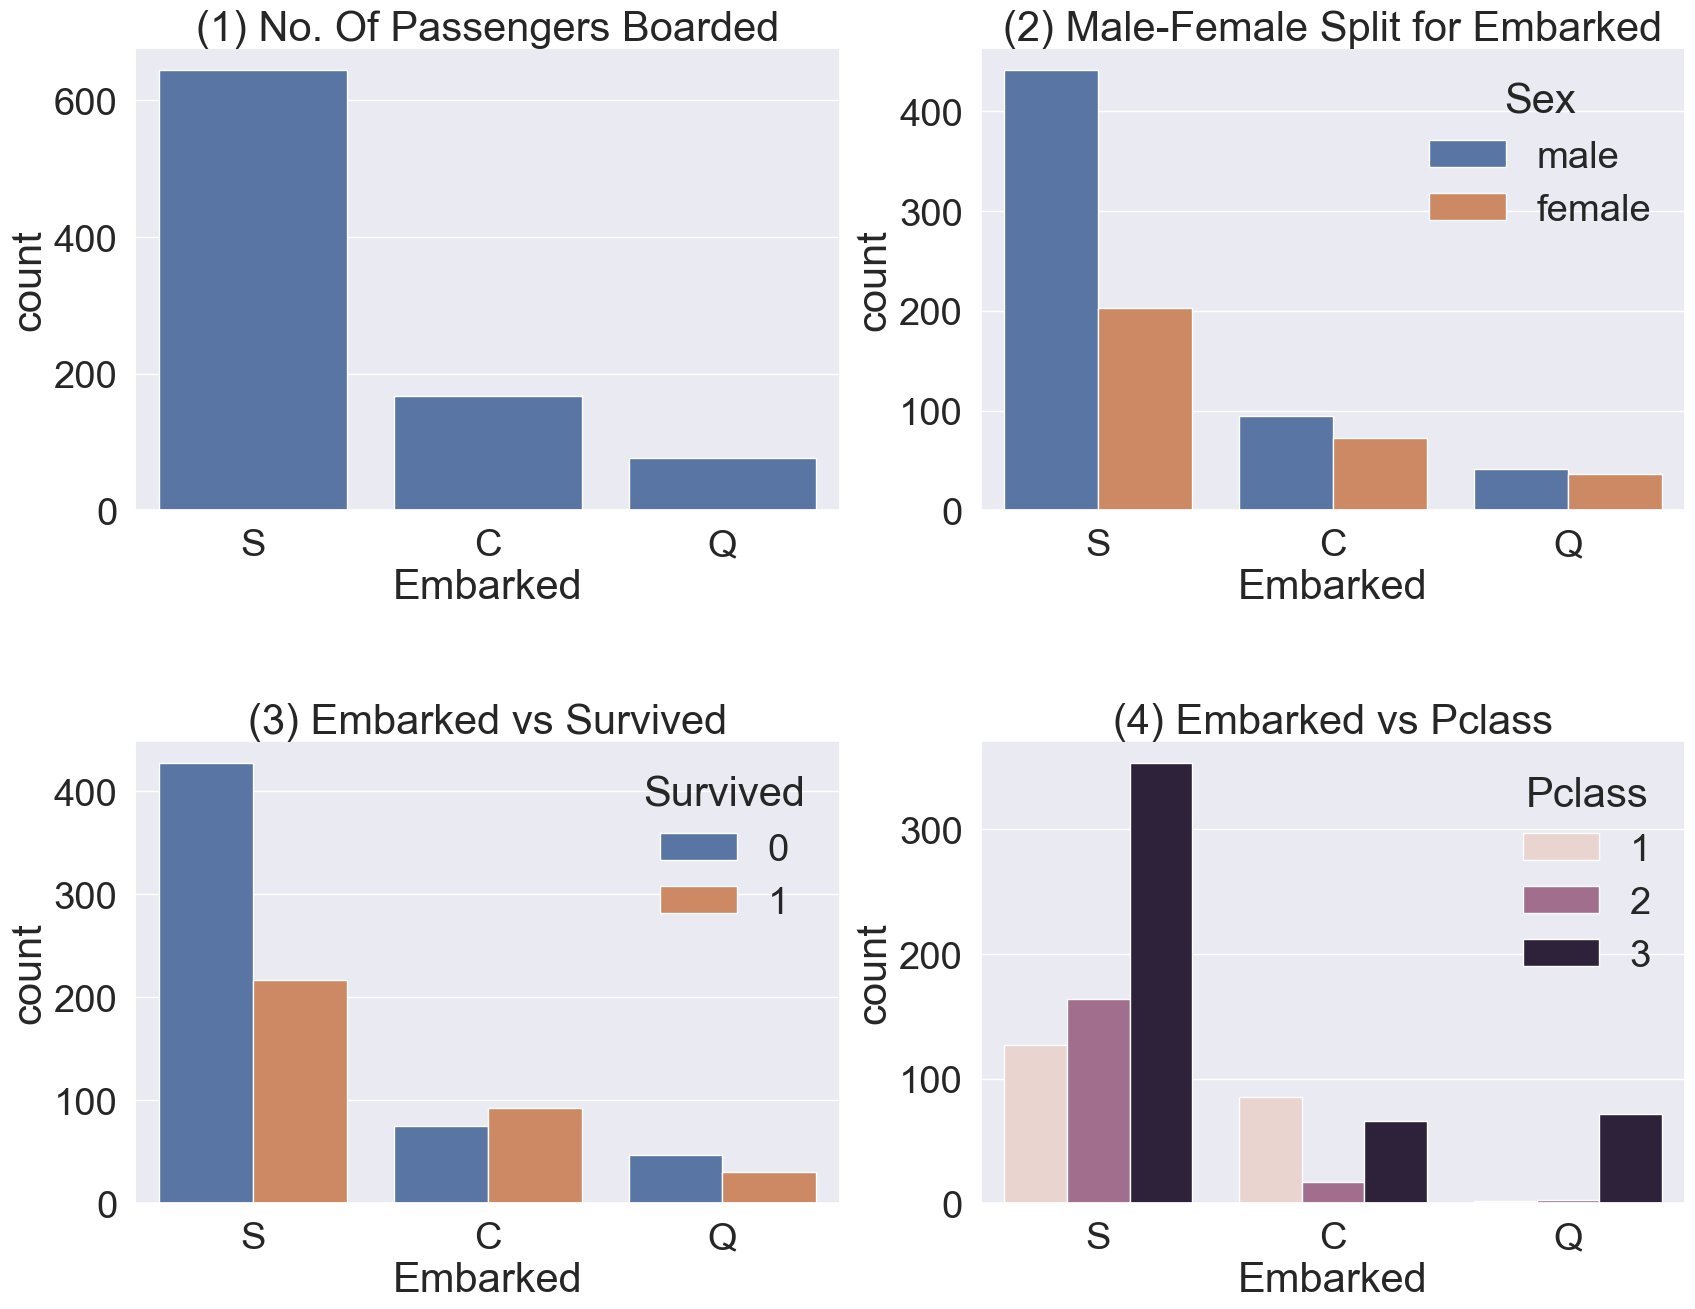

In [36]:
f, ax = plt.subplots(2, 2, figsize=(20,15))
sns.countplot(x='Embarked', data=df_train, ax=ax[0,0])
ax[0,0].set_title('(1) No. Of Passengers Boarded')
sns.countplot(x='Embarked', hue='Sex', data=df_train, ax=ax[0,1])
ax[0,1].set_title('(2) Male-Female Split for Embarked')
sns.countplot(x='Embarked', hue='Survived', data=df_train, ax=ax[1,0])
ax[1,0].set_title('(3) Embarked vs Survived')
sns.countplot(x='Embarked', hue='Pclass', data=df_train, ax=ax[1,1])
ax[1,1].set_title('(4) Embarked vs Pclass')
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

> `plt.subplots_adjust(wspace=0.2, hspace=0.5)` <br>
> **코드해석**<br>
> `wspace (Width Space):`<br>
가로 방향으로 인접한 그래프 사이의 간격을 뜻합니다.<br>
값이 0.2라면, 그래프 자체 너비의 0.2배(20%)만큼 여백을 두라는 의미입니다.<br>
`hspace (Height Space):`<br>
세로 방향으로 위아래 그래프 사이의 간격을 뜻합니다.<br>
값이 0.5라면, 그래프 자체 높이의 0.5배(50%)만큼 여백을 두라는 의미입니다.<br>
보통 그래프의 제목(title)이나 X축 라벨이 아래 그래프와 겹치는 경우가 많아서, wspace보다는 hspace를 조금 더 크게 주는 편입니다.<br>

>**그래프 살펴보기**<br>
>`Figure(1)` - 전체적으로 봤을 때, S 에서 가장 많은 사람이 탑승했습니다.<br>
>`Figure(2)` - C와 Q 는 남녀의 비율이 비슷하고, S는 남자가 더 많습니다.<br>
>`Figure(3)` - 생존확률이 S 경우 많이 낮은 걸 볼 수 있습니다. (이전 그래프에서 봤었습니다)<br>
>`Figure(4)` - Class 로 split 해서 보니, C가 생존확률이 높은건 클래스가 높은 사람이 많이 타서 그렇습니다. S는 3rd class 가 많아서 생존확률이 낮게 나옵니다.<br>

## 2.6 Family - SibSp(형제 자매) + Parch(부모, 자녀)
- `SibSp`와 `Parch`를 합치면 함께 탑승한 가족의 수가 될 것입니다.
- 이 두 피쳐를 더해서 새로운 피쳐 `FamilySize`를 만들어 보도록 하겠습니다. 

In [37]:
df_train['FamilySize'] = df_train['SibSp'] + df_train['Parch'] + 1 # 자신을 포함해야하니 1을 더해야 합니다.
df_test['FamilySize'] = df_test['SibSp'] + df_test['Parch'] + 1 # '나를 제외한 내 친척이 몇 명인가'에 대한 데이터 였으므로.

In [38]:
print("Maximum size of Family", df_train['FamilySize'].max())
print("Minimum size of Family", df_train['FamilySize'].min())

Maximum size of Family 11
Minimum size of Family 1


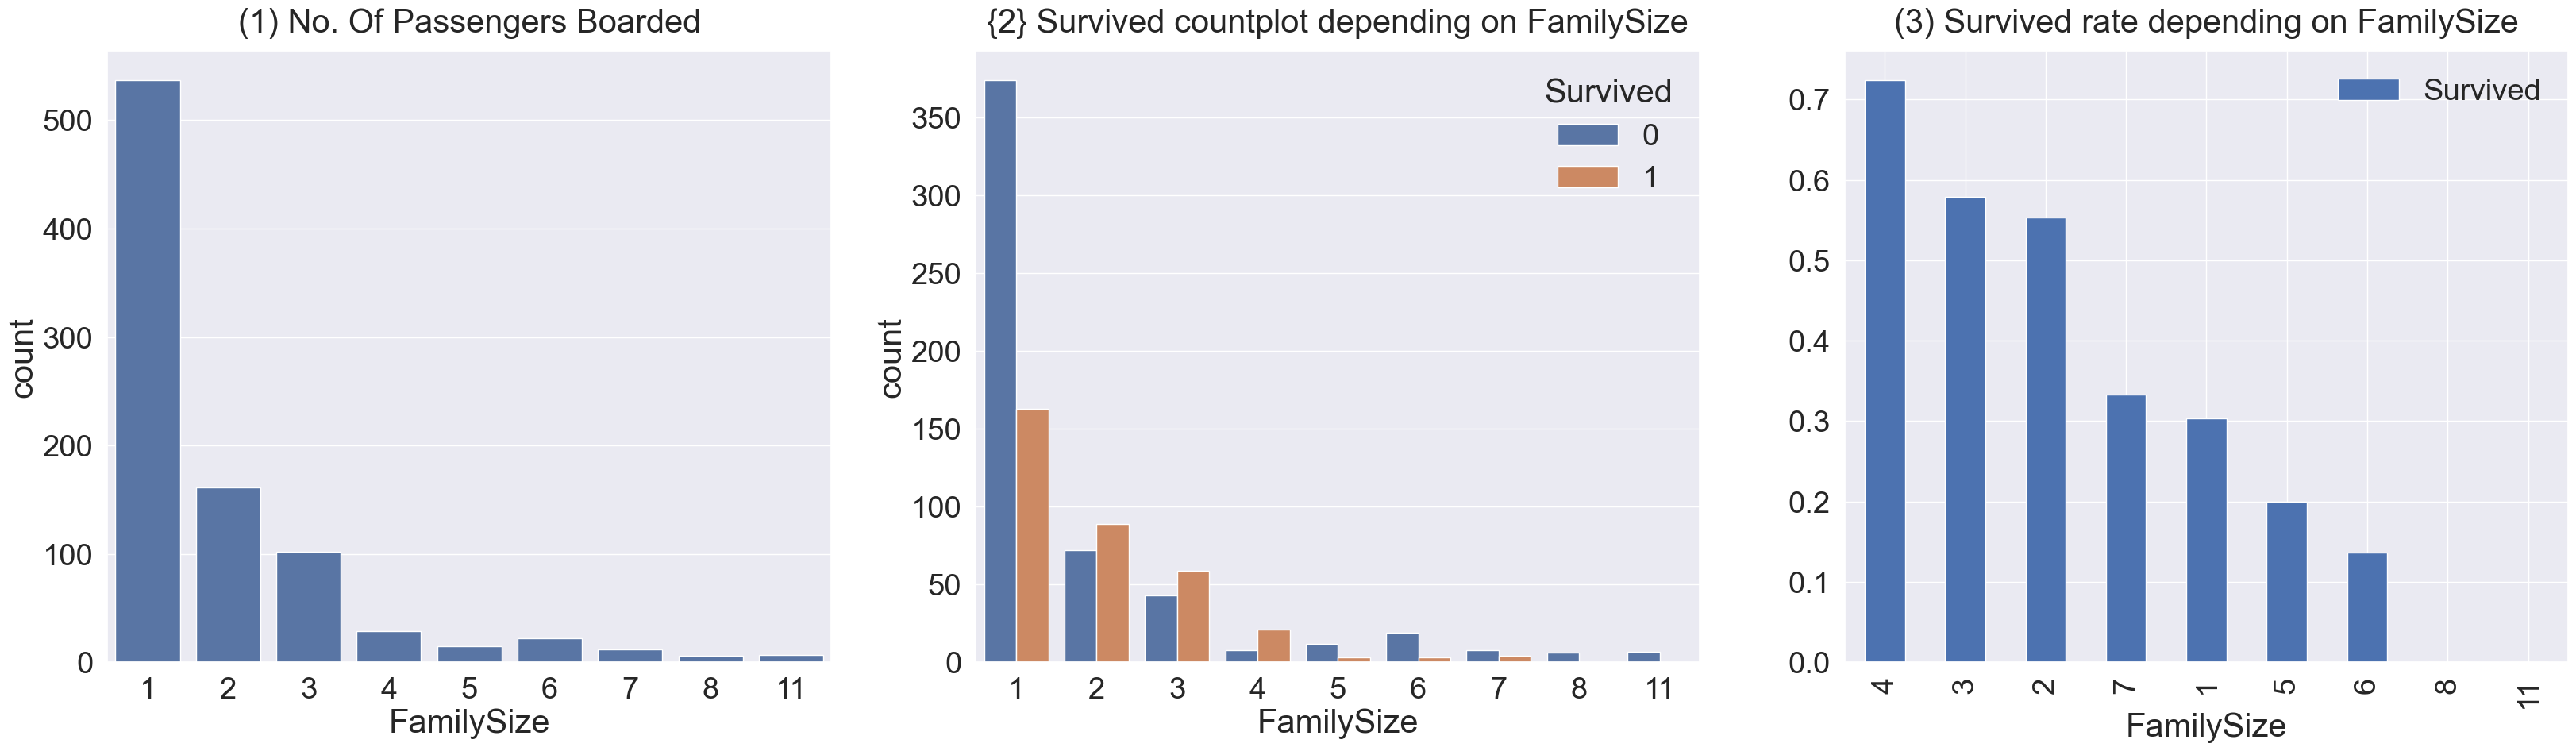

In [39]:
f, ax = plt.subplots(1, 3, figsize=(40, 10))
sns.countplot(x='FamilySize', data=df_train, ax=ax[0])
ax[0].set_title('(1) No. Of Passengers Boarded', y=1.02)

sns.countplot(x='FamilySize', hue='Survived', data=df_train, ax=ax[1])
ax[1].set_title('{2} Survived countplot depending on FamilySize', y=1.02)

df_train[['FamilySize', 'Survived']].groupby(['FamilySize'], as_index=True).mean().sort_values(by='Survived', ascending=False).plot.bar(ax=ax[2])
ax[2].set_title('(3) Survived rate depending on FamilySize', y=1.02)

plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

>**그래프 확인하기**<br>
>가족의 수(`FamilySize`)가 생존(`Survived`)와 선형적인(비례하는) 관계는 아니지만, 분명 생존 확률을 결정짓는 중요한 요소 중 하나이다.<br>
>혼자(1인)보다는 `소가족(2~4인)이 유리`하고, 대가족(5인 이상, 데이터 수가 적음은 고려)은 불리한 것으로 보인다.

## 2.7 Fare
- 탑승 요금 피쳐, histogram 그려보기

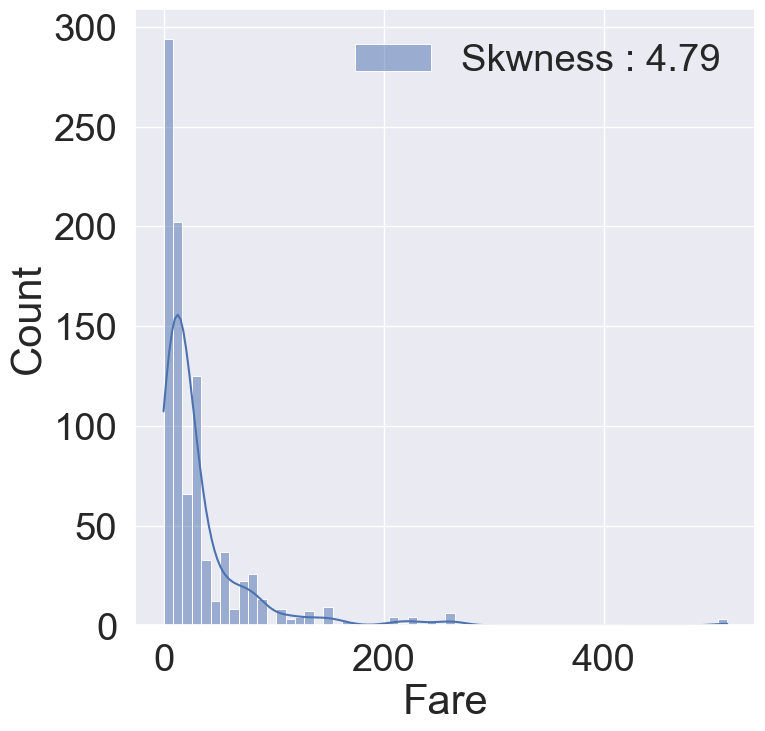

In [40]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
g = sns.histplot(df_train['Fare'], color='b', kde=True, label=f"Skwness : {df_train['Fare'].skew():.2f}", ax=ax)
ax.legend(loc='best')
plt.show()

>**코드 해석**<br>
>`fig, ax = plt.subplots(1, 1, figsize=(8, 8))`<br>
가로 8인치, 세로 8인치 크기의 도화지(fig)를 준비하고, 그 안에 그래프를 그릴 **한 개의 칸(ax)**을 만들어줘.<br>

>`g = sns.histplot(df_train['Fare'], color='b', kde=True, label=f"Skewness : {df_train['Fare'].skew():.2f}", ax=ax)`<br>
요금(Fare) 데이터를 파란색('b') **막대그래프(Histogram)**로 그려줘.<br>
데이터의 흐름을 보여주는 **부드러운 곡선(`kde=True`)**도 같이 그려줘.<br>
그래프의 이름표(label)에는 데이터가 얼마나 한쪽으로 쏠렸는지 나타내는 왜도(Skewness) 값을 소수점 둘째 자리까지 적어줘.<br>
이 모든 그림은 아까 만든 칸(ax)에 그려줘.<br>

>`ax.legend(loc='best')`<br>
방금 만든 이름표(Skewness 정보)를 **범례(설명창)**로 화면에 띄워줘. 위치는 그래프를 가리지 않는 **가장 적절한 곳(best)**에 알아서 배치해줘.

In [41]:
df_test.loc[df_test.Fare.isnull(), 'Fare'] = df_test['Fare'].mean() # 평균값 대체(Mean Imputation)
df_train['Fare'] = df_train['Fare'].map(lambda i: np.log(i) if i > 0 else 0)
df_test['Fare'] = df_test['Fare'].map(lambda i: np.log(i) if i > 0 else 0)

>**코드 해석** <br>
>`df_test.loc[df_test.Fare.isnull(), 'Fare'] = df_test['Fare'].mean()`<br>
① 왼쪽: `df_test.loc[df_test.Fare.isnull(), 'Fare']` (어디에?)<br>
`.loc[행 조건, 열 이름]`: 특정 조건에 맞는 행의 특정 열을 선택하는 함수입니다.<br>
`df_test.Fare.isnull()`: "요금(Fare)이 비어있는(isnull) 행을 다 찾아줘." (여기서는 딱 1명이겠죠?)<br>
`'Fare'`: "그 행들 중에서 오직 'Fare' 칸만 선택해줘."<br>
② 오른쪽: `= df_test['Fare'].mean()` (무엇을?)<br>
`df_test['Fare'].mean()`: "시험용 데이터(test) 승객 전체의 요금 평균을 계산해줘."<br>
`=`: "그 계산된 평균값을 왼쪽에 선택한 빈칸에 집어넣어(할당해)줘."<br>
>
>**전체적인 의미** <br>
>"시험용 데이터(df_test)에서 요금(Fare)이 비어있는 승객을 찾아서, 그 승객의 요금 칸에 시험용 데이터 전체 승객의 평균 요금을 대신 채워 넣어라."<br>
>
>**왜 loc를 사용할까?** <br>
>보시기에 `df_test[df_test.Fare.isnull()]['Fare'] = ...` 처럼 더 간단하게 쓸 수도 있을 것 같지만, 판다스(Pandas)에서는 **.loc**를 사용하는 것을 강력하게 권장합니다.<br>
.loc를 쓰지 않고 값을 바꾸면 **`SettingWithCopyWarning`**이라는 경고가 뜰 때가 많습니다. 이는 "이게 진짜 원본 데이터를 바꾼 건지, 복사본을 바꾼 건지 확실하지 않다"는 경고입니다.<br>
**`.loc`**를 사용하면 **"원본 데이터의 정확한 위치를 집어서 값을 바꿔라"**라는 명확한 명령이 되어 훨씬 안전하고 빠릅니다.<br>
>
>**Null 값이 여러 개 일 때 티켓클래스(Plcass)별 가격의 평균 값을 대체하려면?** <br>
>`df_test['Fare'] = df_test['Fare'].fillna(df_test.groupby('Pclass')['Fare'].transform('mean'))`

>`df_train['Fare'] = df_train['Fare'].map(lambda i: np.log(i) if i > 0 else 0)`

>**코드 이해**<br>
>`.map()`<br>
**의미**: "컬럼에 있는 데이터를 하나하나 꺼내서 특정 규칙을 적용해라"라는 뜻입니다.<br>
**작동**: Fare 열의 첫 번째 승객 요금부터 마지막 승객 요금까지 차례대로 꺼내서 lambda 함수에 전달합니다.<br>
`lambda i :` ... (익명 함수)<br>
**의미**: 함수를 거창하게 정의하지 않고 한 줄로 짧게 쓰고 싶을 때 사용합니다.<br>
`i`: map에 의해 꺼내진 **'요금 하나하나'**를 뜻하는 임시 이름입니다. (x라고 써도 상관없습니다.)<br>
`np.log(i)`<br>
**의미**: NumPy 라이브러리의 자연로그 함수입니다. 숫자를 확 줄여주는 마법의 함수라고 생각하세요.<br>
`if i > 0 else 0`<br>
**의미**: "만약 요금(i)이 0보다 크면 로그를 취하고, 아니면 그냥 0으로 둬라."<br>
**이유**: 수학적으로 로그 함수에 0이나 음수가 들어가면 **에러(-inf)**가 발생합니다. 배를 공짜로 탄 승객들이 가끔 있는데, 이들을 보호하기 위한 안전장치입니다.
>
>**로그변환의 이유**<br>
>10달러와 500달러는 무려 490배 차이가 나지만,<br>
여기에 로그를 취하면 대략 2.3과 6.2 정도로 바뀝니다.<br>
>큰 숫자는 작게 만들어주고, 작은 숫자들 사이의 간격은 넓혀줘서 데이터가 골고루(정규분포에 가깝게) 퍼지게 됩니다.<br>
>이제 숫자들이 서로 비슷비슷한 범위 안으로 들어왔기 때문에, 머신러닝 모델이 훨씬 더 안정적으로 공부할 수 있게 됩니다.<br>

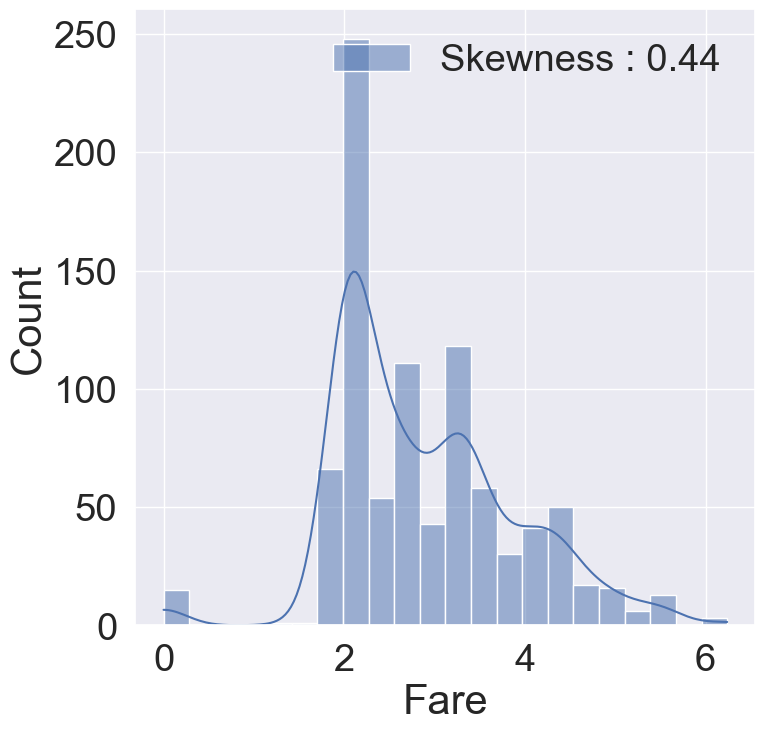

In [42]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
sns.histplot(df_train['Fare'], color='b', kde=True, label=f"Skewness : {df_train['Fare'].skew():.2f}", ax=ax)
ax.legend(loc='best')
# log를 취해 비대칭성을 해소하고, 모델이 좀 더 좋은 성능을 낼 수 있게 한다.

## 2.8 Cabin
: NaN이 약 80%인 feature, 생존에 영향을 미칠 중요한 정보를 얻어내기가 쉽지 않다.

In [43]:
df_train['Cabin'].isnull().sum() / df_train.shape[0] # Cabin 피쳐의 Null 비율 계산

np.float64(0.7710437710437711)

In [44]:
df_train.head()[['PassengerId', 'Cabin']]

,PassengerId,Cabin
0,1,NaN
1,2,C85
2,3,NaN
3,4,C123
4,5,NaN


## Ticket
: NaN이 없는 string data feature

In [45]:
df_train['Ticket'].value_counts()

Ticket
347082      7
CA. 2343    7
1601        7
3101295     6
CA 2144     6
           ..
9234        1
19988       1
2693        1
PC 17612    1
370376      1
Name: count, Length: 681, dtype: int64

# 3. 특성 공학(Frature Engineering)

## 3.1 Fill Null

### 3.1.1 Fill Null in Age using title

In [46]:
df_train['Age'].isnull().sum()

np.int64(177)

In [47]:
df_train['Initial']=df_train.Name.str.extract('([A-Za-z]+)\.')
df_test['Initial']=df_test.Name.str.extract('([A-Za-z]+)\.')

>`df_train['Initial']=df_train.Name.str.extract('([A-Za-z]+)\.')`<br>
>**코드 해석**<br>
>이 코드는 **정규표현식(Regular Expression)**이라는 도구를 사용하여 문자열을 패턴으로 검색합니다.<br>
`df_train.Name.str`: Name 컬럼에 있는 문자열(string) 데이터들을 하나씩 처리하겠다는 뜻입니다.<br>
`.extract(...)`: 특정 패턴에 맞는 글자들만 추출해오라는 명령입니다.<br>

>`'([A-Za-z]+)\.'` (핵심 패턴):<br>
`[A-Za-z]`: 알파벳 대문자(A-Z)와 소문자(a-z)를 찾으라는 뜻입니다.<br>
`+`: 앞에 있는 글자(알파벳)가 하나 이상 반복되는 덩어리를 찾으라는 뜻입니다.<br>
`()`: 괄호로 감싼 부분만 실제로 추출해서 가져오라는 뜻입니다. (이른바 캡처 그룹)<br>
`\.`: 마침표(.)를 찾으라는 뜻입니다. (정규식에서 마침표는 특수한 의미를 갖기 때문에, 진짜 마침표를 찾으려면 앞에 백슬래시\를 붙여야 합니다.)<br>

>**어떻게 작동하나요?** <br>
타이타닉 승객 이름은 보통 Braund, Mr. Owen Harris와 같은 형식입니다.<br>
컴퓨터가 이름을 읽다가 **마침표(.)**를 찾습니다.<br>
마침표 바로 앞에 붙어 있는 알파벳 덩어리를 확인합니다. (Mr)<br>
그 Mr만 쏙 뽑아서 Initial이라는 새로운 칸에 저장합니다.<br>
결과: Mr, Miss, Mrs, Master 같은 호칭들만 모인 컬럼이 탄생합니다.<br>

In [48]:
pd.crosstab(df_train['Initial'], df_train['Sex']).T.style.background_gradient(cmap='YlGnBu', axis=None)
# Checking the Initials with the Sex

Initial,Capt,Col,Countess,Don,Dr,Jonkheer,Lady,Major,Master,Miss,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir
Sex,,,,,,,,,,,,,,,,,
female,0,0,1,0,1,0,1,0,0,182,2,1,0,125,1,0,0
male,1,2,0,1,6,1,0,2,40,0,0,0,517,0,0,6,1


>**코드해석**<br>
>`pd.crosstab(df_train['Initial'], df_train['Sex'])`<br>
"호칭(Initial)과 성별(Sex)을 가로세로로 엮은 교차표를 만들어줘."<br>
예를 들어, 행에는 Mr, Miss, Mrs가 있고 열에는 male, female이 있어서 각각 몇 명씩 있는지 숫자를 세어 표로 만듭니다.<br>
`.T` (Transpose)<br>
"이 표의 행과 열을 서로 뒤집어줘."<br>
원래 '호칭'이 행(줄)이고 '성별'이 열(칸)이었는데, 이를 뒤집어서 성별이 행, 호칭이 열이 되게 만듭니다. (표를 더 길게 혹은 넓게 보기 편하게 바꾸는 작업입니다.)<br>
>`.style.background_gradient(cmap='summer_r')`<br>
"표의 숫자 크기에 따라 배경에 색깔을 칠해줘(그라데이션)."<br>
숫자가 클수록 진한 색, 작을수록 연한 색으로 칠해져서 어디에 데이터가 몰려 있는지 한눈에 알 수 있게 합니다.<br>
`cmap='summer_r'`: 'summer'라는 이름의 색상표(초록~노랑 계열)를 반전(_r)해서 사용하라는 뜻입니다.<br>

>`.style` 이란?
판다스의 데이터프레임(표) 뒤에 .style을 붙이는 순간, 이 표는 단순한 데이터 덩어리가 아니라 **'꾸미기가 가능한 상태'**가 됩니다.<br>
기본 표: 검은 글씨, 흰 배경의 지루한 표.<br>
**`.style` 적용 후**: 글자 색, 배경 색, 테두리 등을 HTML/CSS 문법을 이용해 화려하게 바꿀 수 있습니다.<br>
>`background_gradient` (배경 그라데이션)
이름 그대로 **"숫자의 크기에 따라 배경색을 단계적으로 칠해라"**라는 뜻입니다.<br>
**작동 원리**: 표 안에 있는 숫자들 중에서 최솟값과 최대값을 컴퓨터가 자동으로 찾습니다.<br>
**색상 배정**:<br>
값이 작으면 연한 색 (혹은 색상표의 시작점 색)<br>
값이 크면 진한 색 (혹은 색상표의 끝점 색)<br>
효과: 수많은 숫자 사이에서 어디에 데이터가 몰려 있는지(Hot spot)를 뇌가 숫자를 읽기 전에 눈이 먼저 색깔로 파악하게 도와줍니다. 이를 보통 '히트맵(Heatmap)' 효과라고 부릅니다.<br>

In [49]:
mapping={
    'Mlle' : 'Miss', 'Mme' : 'Miss', 'Ms' : 'Miss',
    'Dr' : 'Mr', 'Major' : 'Mr', 'Capt' : 'Mr', 'Sir' : 'Mr', 'Don' : 'Mr', 'Dona' : 'Mr',
    'Lady' : 'Mrs', 'Countess' : 'Mrs', 'Jonkheer' : 'Other', 'Col' : 'Other', 'Rev' : 'Other'
}
df_train['Initial'].replace(mapping, inplace=True)
df_test['Initial'].replace(mapping, inplace=True)

In [50]:
df_train.groupby('Initial').mean(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize
Initial,,,,,,,,
Master,414.975000,0.575000,2.625000,4.574167,2.300000,1.375000,3.340710,4.675000
Miss,411.741935,0.704301,2.284946,21.860000,0.698925,0.537634,3.123713,2.236559
Mr,455.880907,0.162571,2.381853,32.739609,0.293006,0.151229,2.651507,1.444234
Mrs,456.393701,0.795276,1.984252,35.981818,0.692913,0.818898,3.443751,2.511811
Other,564.444444,0.111111,1.666667,45.888889,0.111111,0.111111,2.641605,1.222222


In [51]:
df_train.groupby('Initial')['Age'].mean()

Initial
Master     4.574167
Miss      21.860000
Mr        32.739609
Mrs       35.981818
Other     45.888889
Name: Age, dtype: float64

<Axes: xlabel='Initial'>

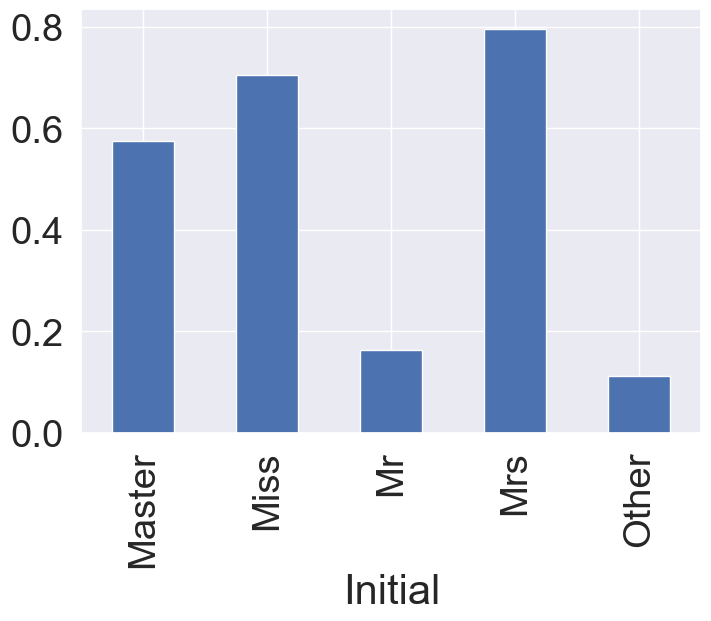

In [52]:
df_train.groupby('Initial')['Survived'].mean().plot.bar()

In [53]:
df_train.loc[(df_train.Age.isnull())&(df_train.Initial=='Mr'), 'Age'] = 33
df_train.loc[(df_train.Age.isnull())&(df_train.Initial=='Mrs'), 'Age'] = 36
df_train.loc[(df_train.Age.isnull())&(df_train.Initial=='Master'), 'Age'] = 5
df_train.loc[(df_train.Age.isnull())&(df_train.Initial=='Miss'), 'Age'] = 22
df_train.loc[(df_train.Age.isnull())&(df_train.Initial=='Other'), 'Age'] - 46

df_test.loc[(df_train.Age.isnull())&(df_test.Initial=='Mr'), 'Age'] = 33
df_test.loc[(df_train.Age.isnull())&(df_test.Initial=='Mrs'), 'Age'] = 36
df_test.loc[(df_train.Age.isnull())&(df_test.Initial=='Master'), 'Age'] = 5
df_test.loc[(df_train.Age.isnull())&(df_test.Initial=='Miss'), 'Age'] = 22
df_test.loc[(df_train.Age.isnull())&(df_test.Initial=='Other'), 'Age'] - 46

Series([], Name: Age, dtype: float64)

In [54]:
df_train.isnull().sum()[df_train.isnull().sum()>0]

Cabin       687
Embarked      2
Age_band    177
dtype: int64

In [55]:
df_test.isnull().sum()[df_test.isnull().sum()>0]

Age       86
Cabin    327
dtype: int64

>`df_train.isnull().sum()[df_train.isnull().sum()>0]`
>**코드해석**<br>
>`df_train.isnull()`<br>
**의미**: 데이터프레임의 모든 칸을 검사해서 비어 있으면 True, 값이 있으면 False로 바꿉니다.<br>
**결과**: 원래 데이터와 똑같은 모양의 True/False 표가 만들어집니다.<br>
`.sum()`<br>
**의미**: 위에서 만든 True/False 표를 컬럼별로 더합니다.<br>
**특징**: 파이썬에서 True는 1로, False는 0으로 계산됩니다.<br>
**결과**: 각 컬럼별로 결측치가 몇 개인지 나타내는 숫자 리스트(Series)가 나옵니다.<br>
예: Age: 177, Fare: 0, Cabin: 687, Embarked: 2 ...<br>
`[df_train.isnull().sum() > 0]` (필터링)<br>
**의미**: "위의 결과 중에서 값이 0보다 큰 것만 골라내줘!"라는 뜻입니다.<br>
**이유**: 결측치가 0개인(깨끗한) 컬럼은 굳이 화면에 띄워서 볼 필요가 없기 때문입니다.<br>
**결과**: **결측치가 하나라도 있는 컬럼들만** 화면에 출력됩니다.<br>

> **왜 이렇게 쓰나요?** <br>
보통 그냥 df_train.isnull().sum()만 써도 결과는 나옵니다. 하지만 데이터의 컬럼이 50개, 100개라면 어떻게 될까요?<br>
**그냥 쓸 때**: 결측치가 0인 컬럼까지 100줄이 넘게 화면에 출력되어 한눈에 보기 힘듭니다.<br>
**위의 코드를 쓸 때**: 진짜 문제가 되는(비어있는) 컬럼 3~4개만 딱 보여주므로 "어떤 데이터를 고쳐야 할지" 바로 파악할 수 있습니다.

>**해석**<br>
>"Age는 177개가 비어있고, Cabin은 687개나 비어있네. Embarked는 2개만 채우면 되겠다!"라고 즉시 판단할 수 있게 됩니다. 

### 3.1.2 Fill Null in Embarked

In [56]:
print('Embarked has', sum(df_train['Embarked'].isnull()), 'Null values')

Embarked has 2 Null values


In [57]:
df_train['Embarked'].fillna('S', inplace=True)

In [58]:
df_train.isnull().sum()[df_train.isnull().sum()>0]

Cabin       687
Age_band    177
dtype: int64

## 3.2 Change Age(continuous to categorical)

In [59]:
def category_age(x):
    if x < 10:
        return 0
    elif x < 20:
        return 1
    elif x < 30:
        return 2
    elif x < 40:
        return 3
    elif x < 50:
        return 4
    elif x < 60:
        return 5
    elif x < 70:
        return 6
    else:
        return 7
df_train['Age_cat'] = df_train['Age'].apply(category_age)
df_test['Age_cat'] = df_test['Age'].apply(category_age)

In [60]:
df_train.groupby(['Age_cat'])['PassengerId'].count()

Age_cat
0     66
1    102
2    256
3    304
4     89
5     48
6     19
7      7
Name: PassengerId, dtype: int64

>**코드 해석**<br>
>**[함수 정의 부분]**<br>
`def category_age(x)`:<br>
**의미**: "나이를 받아서 그룹 번호로 바꿔주는 **category_age라는 이름의 기계(함수)**를 만들겠다"라는 선언입니다.<br>
`x`: 나이 컬럼에서 한 명씩 꺼내온 **'승객 한 명의 나이'**를 뜻합니다.<br>
`if x < 10: return 0 ... else: return 7`<br>
**의미**: "가져온 나이(x)가 어느 구간에 속하는지 검사해서, 그에 맞는 **숫자(0~7)**를 돌려줘라"는 규칙입니다.<br>
**이유**: 21살, 22살처럼 너무 세세한 정보보다는 '20대'라는 뭉뚱그린 정보가 AI 모델이 학습하기에 더 효율적이기 때문입니다. (이를 데이터 요약이라고 합니다.)<br>
**[적용 부분]**<br>
`df_train['Age'].apply(category_age)`<br>
`.apply()`<br>
**의미**: "방금 만든 category_age라는 규칙을, 이 컬럼의 모든 데이터에 하나하나 적용해라!"라는 명령어입니다.<br>
**작동**: 'Age' 열의 첫 번째 데이터부터 마지막까지 기계(category_age)에 집어넣고 결과값을 받아옵니다.<br>
`df_train['Age_cat'] = ...`<br>
**의미**: 함수를 통과해서 나온 결과값들(0, 1, 2...)을 모아서 Age_cat이라는 새로운 이름의 열에 저장하라는 뜻입니다.

>**왜 apply를 쓸까?** 컨베이어 벨트 비유<br>
데이터프레임을 공장의 컨베이어 벨트라고 상상해 보세요.<br>
Age라는 벨트 위에 승객들의 나이가 쭉 지나가고 있습니다.<br>
.apply(함수)는 그 벨트 옆에 '특정 작업(함수)'을 하는 로봇 팔을 하나 세우는 것과 같습니다.<br>
로봇 팔은 지나가는 나이를 하나씩 집어서(x), 우리가 정한 규칙대로 처리한 뒤 다시 벨트 위에 올려놓습니다.<br>

>**apply vs map 차이는 무엇일까?** <br>
**map**: 주로 단순한 치환에 씁니다. (예: 'male'은 0으로, 'female'은 1로 바꿔라!)<br>
**apply**: 훨씬 복잡한 로직을 쓸 때 유용합니다. if-elif-else가 길게 들어가는 복잡한 계산은 apply를 쓰는 것이 가독성도 좋고 훨씬 깔끔합니다.<br>

>**왜 lambda 대신 def를 썼을까?** <br>
lambda를 써서 한 줄로 끝낼 수 있는데, 왜 def로 길게 썼을까요?<br>
내용이 너무 길기 때문입니다. lambda는 한 줄짜리 간단한 식에 어울립니다.<br>
조건문(if)이 7~8개나 들어가는 경우에는 lambda로 쓰면 코드가 너무 길어져서 읽기가 힘듭니다. 그래서 따로 함수를 정의(def)하고 이름만 apply에 전달하는 방식을 선택한 것입니다.<br>

>**NaN이 많을 때** <br>
타이타닉 데이터에서 **'나이(Age)'**는 빈칸(NaN)이 많은 데이터입니다.<br>
지금 작성하신 코드는 아주 훌륭하지만, 나중에 **나이 정보가 없는 사람(NaN)**을 만났을 때 에러가 날 수도 있습니다.<br>
그럴 때는 함수 맨 위에 if np.isnan(x): return 3 (나이를 모르면 대충 평균치인 30대 그룹으로 넣어라) 같은 코드를 추가하기도 합니다.<br>

## 3.3 Change Initial, Embarked and Sex(string to numerical)
: Mr, Mrs, Miss, Master, Other을 컴퓨터가 인식할 수 있도록 수치화하기

In [61]:
df_train['Initial'] = df_train['Initial'].map({'Master':0, 'Miss':1, 'Mr':2, 'Mrs':3, 'Other':4})
df_test['Initial'] = df_test['Initial'].map({'Master':0, 'Miss':1, 'Mr':2, 'Mrs':3, 'Other':4})

In [62]:
df_train['Embarked'] = df_train['Embarked'].map({'C':0, 'Q':1, 'S':2})
df_test['Embarked'] = df_test['Embarked'].map({'C':0, 'Q':1, 'S':2})

In [63]:
df_train['Embarked'].isnull().any(), df_train['Embarked'].dtypes

(np.False_, dtype('int64'))

In [64]:
df_train['Sex'] = df_train['Sex'].map({'female':0, 'male':1})
df_test['Sex'] = df_test['Sex'].map({'female':0, 'male':1})

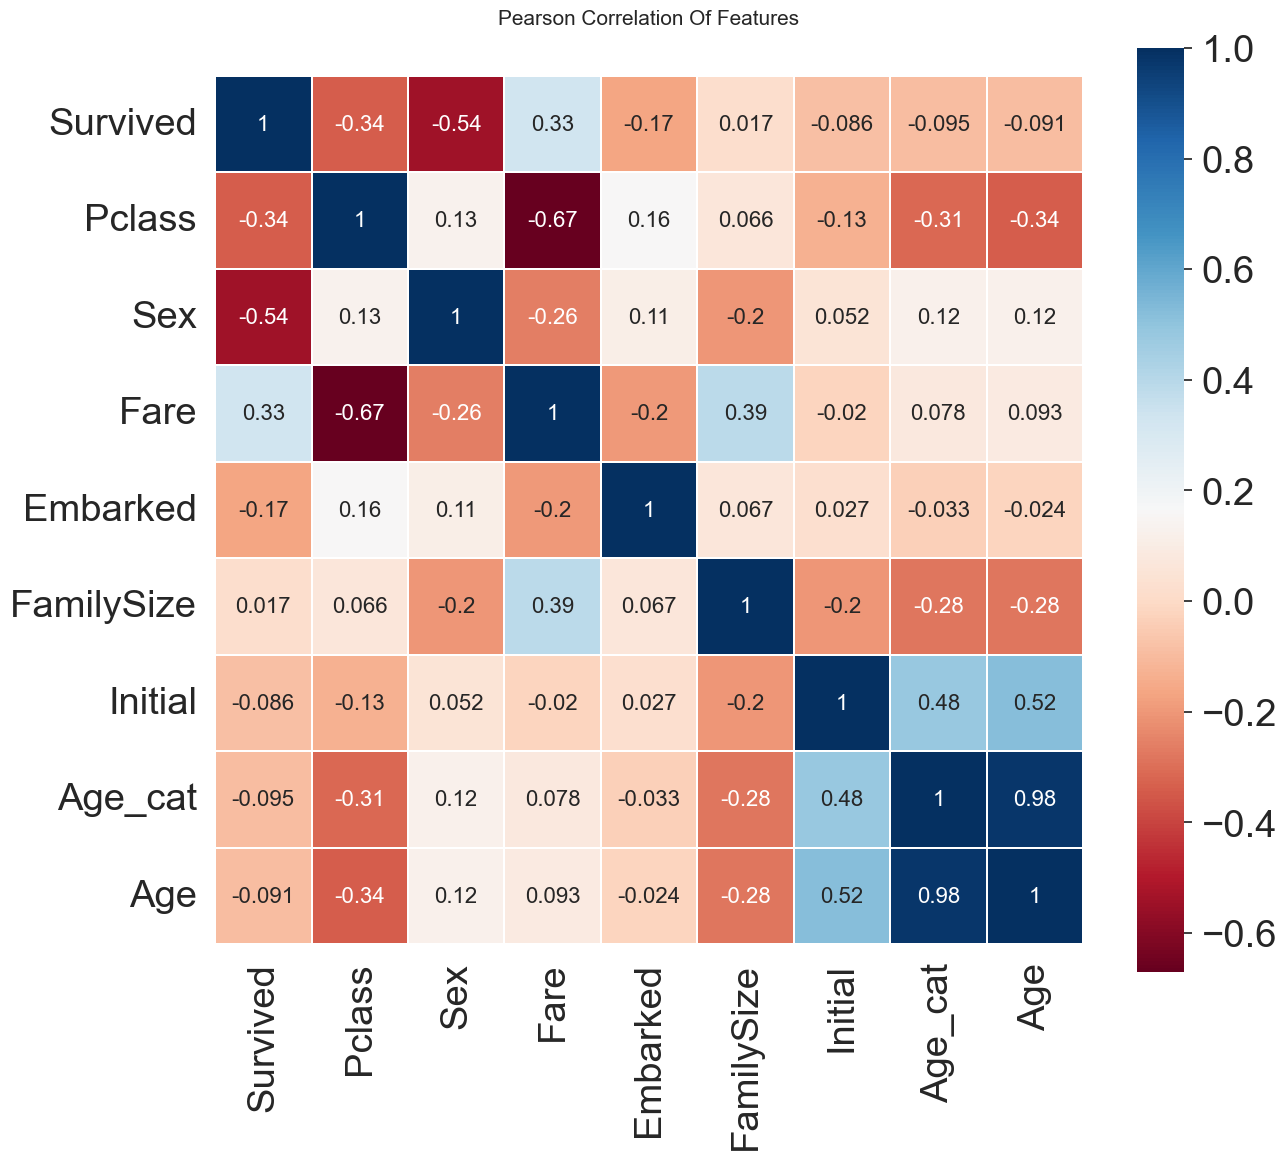

In [65]:
heatmap_data = df_train[['Survived', 'Pclass', 'Sex', 'Fare', 'Embarked', 'FamilySize', 'Initial', 'Age_cat', 'Age']]
colormap = plt.cm.RdBu
plt.figure(figsize=(14,12))
plt.title('Pearson Correlation Of Features', y=1.05, size=15)
sns.heatmap(heatmap_data.astype(float).corr(), linewidths=0.1, vmax=1.0, square=True, cmap=colormap, linecolor='white', annot=True, annot_kws={"size":16})
del heatmap_data

>**HeatMap 그리기**<br>

>**`heatmap_data = df_train[['Survived', 'Pclass', 'Sex', 'Fare', 'Embarked', 'FamilySize', 'Initial', 'Age_cat', 'Age']]`**<br>
**-해석**: 전체 데이터(df_train) 중에서 상관관계를 분석하고 싶은 특정 컬럼(열)들만 쏙쏙 뽑아서 heatmap_data라는 이름의 바구니에 담는 과정입니다.<br>
**-의미**: 생존 여부(Survived), 객실 등급(Pclass), 성별(Sex) 등 우리가 궁금한 항목들만 모아서 비교하겠다는 뜻입니다.<br>

>**`colormap = plt.cm.RdBu`**<br>
**-해석**: 그래프에 사용할 **색상 규칙(컬러맵)**을 정합니다.<br>
**-의미**: RdBu는 **Red(빨강)와 Blue(파랑)**의 약자입니다. 보통 상관관계 양의 관계면 파란색, 음의 관계면 빨간색으로 표시하여 시각적으로 확연히 구분되게 해줍니다.<br>

>**`plt.figure(figsize=(14, 12))`**<br>
**-해석**: 그래프를 그릴 도화지의 크기를 정합니다.<br>
**-의미**: 가로 14인치, 세로 12인치 크기로 꽤 큼직하게 만들겠다는 뜻입니다. 항목이 많기 때문에 글자가 겹치지 않게 크게 잡은 것입니다.<br>

>**`plt.title('Pearson Correlation Of Features', y=1.05, size=15)`** <br>
**-해석**: 그래프 맨 위에 제목을 붙입니다.
**`y=1.05`**: 제목의 높이입니다. 1.0보다 조금 높게 설정해서 그래프 본문과 살짝 떨어뜨려 가독성을 높였습니다.
**`size=15`**: 글자 크기를 15로 설정했습니다.

>**`sns.heatmap(heatmap_data.astype(float).corr(), linewidths=0.1, vmax=1.0, square=True, cmap=colormap, linecolor='white', annot=True, annot_kws={"size":16})`**<br>

>**`heatmap_data.astype(float).corr():`**<br>
>`astype(float)`: 데이터를 실수(소수점) 형태로 바꿉니다.<br>
`.corr()`: 상관계수를 계산합니다.<br>
`linewidths=0.1`: 칸과 칸 사이의 간격(선 굵기)입니다.<br>
`vmax=1.0`: 색상의 최대 수치를 1.0으로 고정합니다. (상관계수는 최대가 1이기 때문입니다.)<br>
`square=True`: 각 칸의 모양을 정사각형으로 만듭니다.<br>
`cmap=colormap`: 아까 위에서 정한 빨강-파랑 색상을 적용합니다.<br>
`linecolor='white'`: 칸 사이 구분선의 색상을 하얀색으로 칠합니다.<br>
`annot=True`: 'Annotation'의 약자로, 칸 안에 실제 상관계수 숫자를 표시하라는 뜻입니다.<br>
`annot_kws={"size":16}`: 칸 안에 들어가는 숫자의 크기를 16으로 설정합니다.<br>

>**`del heatmap_data`**
>**-해석**: 이제 그래프를 다 그렸으니, 데이터를 담아두었던 임시 바구니(heatmap_data)를 삭제합니다. "메모리 정리"
**-의미**: 파이썬에게 "이 변수는 이제 안 쓸 거니까 메모리에서 지워줘!"라고 말하는 것입니다. 데이터가 매우 클 때 컴퓨터의 메모리를 아끼기 위해 사용하는 좋은 습관입니다.

## One-hot encoding on initial and Embarked

In [66]:
df_train = pd.get_dummies(df_train, columns=['Initial'], prefix='Initial')
df_test = pd.get_dummies(df_test, columns=['Initial'], prefix='Initial')

In [67]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_band,FamilySize,Age_cat,Initial_0,Initial_1,Initial_2,Initial_3,Initial_4
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,1.981001,NaN,2,"(16.336, 24.294]",2,2,False,False,True,False,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,4.266662,C85,0,"(32.252, 40.21]",2,3,False,False,False,True,False
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,2.070022,NaN,2,"(24.294, 32.252]",1,2,False,True,False,False,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,3.972177,C123,2,"(32.252, 40.21]",2,3,False,False,False,True,False
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,2.085672,NaN,2,"(32.252, 40.21]",1,3,False,False,True,False,False


>**코드해석**<br>
>`df_train`: 작업을 수행할 데이터프레임입니다.<br>
`columns=['Initial']`: 변환할 컬럼을 지정합니다. 여기서는 호칭(Mr, Mrs 등)이 담긴 Initial 컬럼을 선택했습니다.<br>
`prefix='Initial'`: 새로 만들어질 컬럼 이름 앞에 붙을 접두사를 정합니다. (예: Initial_Mr, Initial_Mrs)

In [68]:
df_train = pd.get_dummies(df_train, columns=['Embarked'], prefix='Embarked')
df_test = pd.get_dummies(df_test, columns=['Embarked'], prefix='Embarked')

## 3.5 Drop Columns

In [69]:
df_train.drop(['PassengerId', 'Name', 'SibSp', 'Parch', 'Ticket', 'Cabin'], axis=1, inplace=True)
df_test.drop(['PassengerId', 'Name', 'SibSp', 'Parch', 'Ticket', 'Cabin'], axis=1, inplace=True) # Axis=1 : 칼럼(열)을 기준으로 작동한다, 칼럼을 삭제하거나 수정할 때 사용한다. 

In [70]:
df_train.head()

,Survived,Pclass,Sex,Age,Fare,Age_band,FamilySize,Age_cat,Initial_0,Initial_1,Initial_2,Initial_3,Initial_4,Embarked_0,Embarked_1,Embarked_2
0,0,3,1,22.0,1.981001,"(16.336, 24.294]",2,2,False,False,True,False,False,False,False,True
1,1,1,0,38.0,4.266662,"(32.252, 40.21]",2,3,False,False,False,True,False,True,False,False
2,1,3,0,26.0,2.070022,"(24.294, 32.252]",1,2,False,True,False,False,False,False,False,True
3,1,1,0,35.0,3.972177,"(32.252, 40.21]",2,3,False,False,False,True,False,False,False,True
4,0,3,1,35.0,2.085672,"(32.252, 40.21]",1,3,False,False,True,False,False,False,False,True


In [71]:
df_train.dtypes

Survived         int64
Pclass           int64
Sex              int64
Age            float64
Fare           float64
Age_band      category
FamilySize       int64
Age_cat          int64
Initial_0         bool
Initial_1         bool
Initial_2         bool
Initial_3         bool
Initial_4         bool
Embarked_0        bool
Embarked_1        bool
Embarked_2        bool
dtype: object

In [72]:
df_test.head()

,Pclass,Sex,Age,Fare,FamilySize,Age_cat,Initial_0,Initial_1,Initial_2,Initial_3,Initial_4,Embarked_0,Embarked_1,Embarked_2
0,3,1,34.5,2.057860,1,3,False,False,True,False,False,False,True,False
1,3,0,47.0,1.945910,2,4,False,False,False,True,False,False,False,True
2,2,1,62.0,2.270836,1,6,False,False,True,False,False,False,True,False
3,3,1,27.0,2.159003,1,2,False,False,True,False,False,False,False,True
4,3,0,22.0,2.508582,3,2,False,False,False,True,False,False,False,True


In [73]:
df_test.dtypes

Pclass          int64
Sex             int64
Age           float64
Fare          float64
FamilySize      int64
Age_cat         int64
Initial_0        bool
Initial_1        bool
Initial_2        bool
Initial_3        bool
Initial_4        bool
Embarked_0       bool
Embarked_1       bool
Embarked_2       bool
dtype: object